Initialize KAN

In [1]:
from kan import *
import torch
torch.set_default_dtype(torch.float64)
device = torch.device('cpu')
print(device)


cpu


Create dataset

In [2]:
from kan.utils import create_dataset
f = lambda x: torch.prod(x, dim=1, keepdim=True)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [4]:
from kan import experiment
results = experiment.runner1(width=[2, 2 ,1], dataset=dataset, steps=200, grids=[3, 5, 10, 20, 50, 100], prune_round=1, refine_round=6)

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                          | 0/200 [00:00<?, ?it/s]

| train_loss: 6.04e-03 | test_loss: 6.20e-03 | reg: 6.86e+00 | : 100%|█| 200/200 [01:38<00:00,  2.04


saving model version 0.1
saving model version 0.2


| train_loss: 2.39e-03 | test_loss: 2.68e-03 | reg: 7.08e+00 | : 100%|█| 200/200 [01:11<00:00,  2.79


...

saving model version 0.7
saving model version 0.8


| train_loss: 4.45e-05 | test_loss: 1.40e-04 | reg: 7.06e+00 | : 100%|█| 200/200 [02:31<00:00,  1.32


saving model version 0.9
saving model version 0.10


| train_loss: 5.70e-05 | test_loss: 1.25e-03 | reg: 7.05e+00 | : 100%|█| 200/200 [03:04<00:00,  1.09

saving model version 0.11


In [6]:
np.savez('6-grid-no-prune.npz', **results)

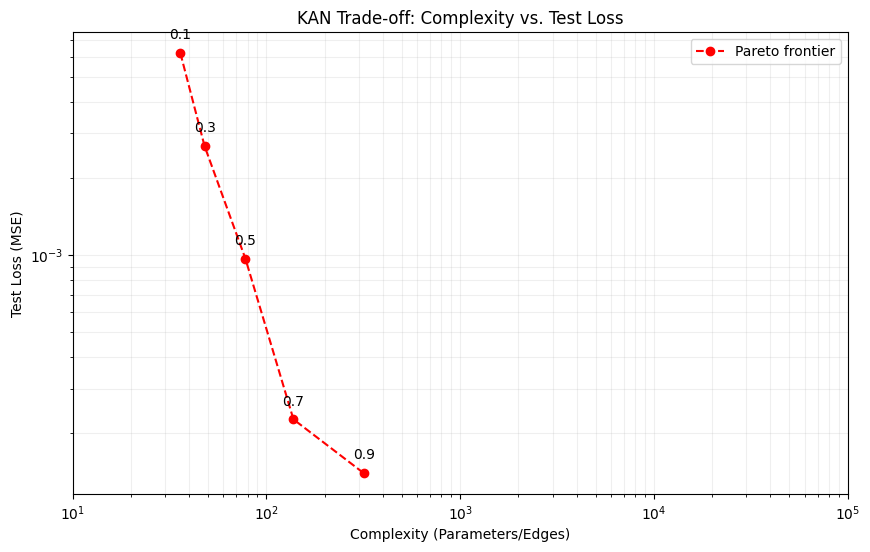

In [ ]:
complexity = results['c'] * (results['G'] + 3)
test_loss = results['test_loss']

x_pf, y_pf, pf_id = experiment.pareto_frontier(complexity, test_loss)

sort_idx = np.argsort(x_pf)
x_pf = x_pf[sort_idx]
y_pf = y_pf[sort_idx]

plt.figure(figsize=(10, 6))


plt.plot(x_pf, y_pf, color='red', marker='o', linestyle='--', label='Pareto frontier')

ids = results['id']
for i, txt in enumerate(pf_id):
    plt.annotate(ids[txt], (x_pf[i], y_pf[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Complexity (Parameters/Edges)')
plt.ylabel('Test Loss (MSE)')
plt.title('KAN Trade-off: Complexity vs. Test Loss')
plt.xlim(1e1, 1e5)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()